# DistilBERT for Fake News Detection / DistilBERT 假新闻检测

This notebook fine-tunes DistilBERT on the same debiased dataset used in `02_lstm_corrected.ipynb`, enabling a fair comparison between the optimised LSTM and a Transformer-based model.

本 notebook 在与 `02_lstm_corrected.ipynb` 完全相同的去偏数据上微调 DistilBERT，目的是在同等条件下对比优化版 LSTM 与 Transformer 模型的表现。

---

**为什么选 DistilBERT？/ Why DistilBERT?**

DistilBERT 是 BERT 的轻量蒸馏版本，体积缩小 40%，速度提升 60%，同时保留了 97% 的语言理解能力。与 LSTM 从零学习词向量不同，DistilBERT 带有在大规模语料上预训练好的上下文词向量，对语言有更深层的理解——这正是处理真假新闻细微写作风格差异所需要的能力。

DistilBERT is a distilled version of BERT — 40% smaller and 60% faster, retaining 97% of BERT's language understanding. Unlike LSTM which learns word representations from scratch, DistilBERT brings pretrained contextual embeddings, giving it a fundamentally richer understanding of language — exactly what is needed to capture subtle stylistic differences between real and fake news.

## 1. Imports / 导入库

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import html as html_module

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import get_scheduler
from torch.optim import AdamW

os.makedirs('../results', exist_ok=True)

# 优先使用 Apple Silicon GPU（MPS），其次 CUDA，最后 CPU
# Use Apple Silicon GPU (MPS) if available, then CUDA, then CPU
device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

/Users/sl1425/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps
PyTorch: 2.8.0


## 2. Load & Clean Data / 加载与清洗数据

与 `02_lstm_corrected.ipynb` 完全相同的九步清洗流程，确保两个模型在同一干净数据上对比。

Identical nine-step cleaning pipeline as `02_lstm_corrected.ipynb` — ensures any difference in results is attributable to model architecture, not data.

In [3]:
fake = pd.read_csv('../data/raw/Fake.csv')
true = pd.read_csv('../data/raw/True.csv')
fake['label'] = 0
true['label'] = 1
df = pd.concat([fake, true]).sample(frac=1, random_state=42).reset_index(drop=True)

df = df.drop(columns=['subject', 'date'])

df['text'] = df['text'].str.replace(r'[\w\s]+\(Reuters\)\s*-?\s*', '', regex=True)
df['text'] = df['text'].str.replace(r'Reuters', '', regex=False)
df['text'] = df['text'].str.replace(r'^\s*[A-Z][A-Z\s\.]+\s*-\s*', '', regex=True)
df['text'] = df['text'].str.replace(r'[\w\s]+\((AP|AFP|UPI)\)\s*-?\s*', '', regex=True)
df['text'] = df['text'].str.replace(r'\b(AP|AFP|UPI)\b', '', regex=True)
df['text'] = df['text'].str.replace(r'http\S+|www\.\S+', '', regex=True)
df['text'] = df['text'].str.replace(r'@\w+', '', regex=True)
df['text'] = df['text'].apply(html_module.unescape)
df['text'] = df['text'].str.replace(r'[^\x00-\x7F]+', ' ', regex=True)
df['text'] = df['text'].str.strip()
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True)

df['content'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
before = len(df)
df = df[df['content'].str.split().str.len() > 10].reset_index(drop=True)

print(f'Total after cleaning: {len(df):,} rows ({before - len(df)} removed)')
df[['content', 'label']].head(3)

Total after cleaning: 44,804 rows (94 removed)


,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1


清洗流程与 `02_lstm_corrected.ipynb` 完全一致，两个模型看到的是同一份数据，结果的差异只能来自模型架构本身。

Cleaning is identical to `02_lstm_corrected.ipynb`. Any performance difference between this model and the optimised LSTM reflects the architecture, not the data.

## 3. Tokenisation & Dataset / 分词与数据集

DistilBERT 的分词方式与 LSTM 完全不同。LSTM 使用自己从训练集建立的词表；DistilBERT 使用预训练时固定下来的 WordPiece 分词器，能把未见过的词拆成子词片段处理。

DistilBERT's tokenisation is fundamentally different from LSTM's. LSTM built its own vocabulary from the training set; DistilBERT uses a fixed pretrained WordPiece tokeniser that can handle unseen words by splitting them into subword pieces.

In [4]:
# 划分训练测试集，与 LSTM 使用相同的 random_state 保证数据一致
# Train/test split — same random_state as LSTM for consistency
X_train, X_test, y_train, y_test = train_test_split(
    df['content'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 35,843  |  Test: 8,961


In [5]:
# 加载预训练的 DistilBERT 分词器
# Load pretrained DistilBERT tokeniser
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# 测试分词效果 / Test tokenisation
sample = X_train[0][:100]
tokens = tokenizer(sample, truncation=True, max_length=256)
print(f'Sample text: {sample}')
print(f'Token count: {len(tokens["input_ids"])}')

Sample text: Republican congressional candidate in Montana cited after incident with reporter - sheriff () - Mont
Token count: 18


第一次运行时会自动从 HuggingFace 下载四个分词器文件（词表、配置等），之后会缓存在本地，无需重复下载。输出中 `Token count: 18` 表示那段文字被拆成了 18 个 token——WordPiece 会把某些词进一步拆成子词（如 `"Montana"` 可能变成 `["mont", "##ana"]`），所以 token 数通常多于词数。

On first run, four tokeniser files are automatically downloaded from HuggingFace and cached locally. `Token count: 18` shows the sample was split into 18 WordPiece tokens — subword splitting means token count is typically higher than word count, as words like `"Montana"` may become `["mont", "##ana"]`.

In [6]:
class NewsDataset(Dataset):
    """把文章列表和标签封装成 PyTorch Dataset，供 DataLoader 批量加载。
    Wraps article texts and labels into a PyTorch Dataset for batched loading."""

    def __init__(self, texts, labels, tokenizer, max_length=128):
        # 截断/补齐至 max_length=128（从 256 减半，训练速度约提升 4 倍，准确率影响极小）
        # Truncate/pad to max_length=128 (halved from 256 — ~4x faster, minimal accuracy loss)
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

# 创建训练集和测试集 Dataset / Create train and test datasets
train_dataset = NewsDataset(X_train, y_train, tokenizer)
test_dataset  = NewsDataset(X_test,  y_test,  tokenizer)

# 创建 DataLoader，训练集打乱顺序，测试集不打乱
# DataLoaders — shuffle train, keep test ordered
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches:  {len(test_loader)}')

Train batches: 2241
Test batches:  561


这一步和 LSTM 的预处理有三个关键区别：

1. **分词器不同**：LSTM 用自建词表把词映射成编号；DistilBERT 用 WordPiece，能把 `"unhelpful"` 拆成 `["un", "##helpful"]`，对未见词的处理更灵活
2. **attention_mask**：DistilBERT 需要额外传入一个 mask，告诉模型哪些位置是真实内容、哪些是补齐的零，LSTM 没有这个机制
3. **batch_size 更小（16 vs 64）**：DistilBERT 参数量远大于 LSTM，每个样本占用更多显存，需要用更小的 batch

Three key differences from LSTM preprocessing: (1) WordPiece tokenisation handles unknown words by splitting into subwords; (2) attention_mask tells the model which positions are real content vs padding — LSTM has no equivalent; (3) smaller batch size (16 vs 64) because DistilBERT's larger parameter count requires more memory per sample.

## 4. Load Model & Training Setup / 加载模型与训练配置

加载预训练的 DistilBERT 模型，并在顶部加一个二分类头（输出层），使其适用于真假新闻分类任务。

Load the pretrained DistilBERT model and attach a binary classification head on top, adapting it for the fake news detection task.

In [7]:
# 加载预训练 DistilBERT，num_labels=2 表示二分类
# Load pretrained DistilBERT with a binary classification head
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)
model = model.to(device)

# AdamW 优化器：比普通 Adam 更适合 Transformer，对权重衰减处理更正确
# AdamW optimiser: better suited for Transformers than standard Adam
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# 学习率调度器：先线性预热，再线性衰减，防止初期更新步幅过大破坏预训练权重
# LR scheduler: linear warmup then linear decay — protects pretrained weights early on
num_epochs = 3
num_training_steps = num_epochs * len(train_loader)
num_warmup_steps   = num_training_steps // 10

scheduler = get_scheduler(
    'linear',
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

print(f'Total training steps: {num_training_steps:,}')
print(f'Warmup steps:         {num_warmup_steps:,}')
print(f'Model parameters:     {sum(p.numel() for p in model.parameters()):,}')

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total training steps: 6,723
Warmup steps:         672
Model parameters:     66,955,010


输出中的 `Some weights were not initialised` 是预期的警告，不是错误——DistilBERT 主体的预训练权重完整加载，只有顶部新加的分类头是随机初始化的，训练的目的就是把这个分类头调整好。模型共约 **6700 万个参数**，远多于优化版 LSTM，这也是 DistilBERT 语言理解能力更强的根本原因。

The `Some weights were not initialised` message is expected — the pretrained DistilBERT body is fully loaded; only the newly added classification head is randomly initialised, which is exactly what fine-tuning will fix. The model has approximately **66.9 million parameters**, far more than the optimised LSTM, which underlies its stronger language understanding capacity.

这里有三个与 LSTM 不同的设计决策：

**AdamW 而非 Adam**：Transformer 的训练中，普通 Adam 对权重衰减的实现有缺陷，AdamW 修正了这个问题，是微调 BERT 类模型的标准选择。学习率设为 `2e-5`，远小于 LSTM 的默认值（约 `1e-3`），因为 DistilBERT 已经有很好的预训练权重，不需要大幅更新。

**学习率预热（Warmup）**：训练开始的前 10% 步骤，学习率从 0 线性增加到 `2e-5`，之后再线性衰减。这是为了保护预训练好的权重——如果一开始学习率太大，会把预训练学到的知识破坏掉。

**只训练 3 个 epoch**：LSTM 训练了 10 个 epoch；DistilBERT 只需要 3 个，因为预训练权重已经非常好，微调不需要太多轮次。

Three design decisions different from LSTM: **AdamW** fixes a weight decay issue in standard Adam and is the standard choice for fine-tuning BERT-family models; the small learning rate (`2e-5`) avoids overwriting pretrained knowledge. **Warmup** gradually increases the learning rate in the first 10% of steps to protect pretrained weights from large early updates. **3 epochs** is sufficient because pretrained weights already encode strong language understanding — LSTM needed 10 epochs to learn from scratch.

## 5. Training Loop / 训练循环

PyTorch 需要手动写训练循环，比 Keras 的 `model.fit()` 更繁琐，但控制更精细。每个 epoch 包含训练阶段和验证阶段。

PyTorch requires a manual training loop — more verbose than Keras `model.fit()` but gives finer control. Each epoch includes a training phase and a validation phase.

In [8]:
from tqdm.auto import tqdm

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
best_val_acc = 0
patience_counter = 0
PATIENCE = 2

for epoch in range(num_epochs):
    # ── 训练阶段 / Training phase ──────────────────────────────────
    model.train()
    total_train_loss = 0
    train_preds_ep, train_labels_ep = [], []

    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]'):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()
        train_preds_ep.extend(outputs.logits.argmax(dim=1).cpu().numpy())
        train_labels_ep.extend(labels.cpu().numpy())

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = accuracy_score(train_labels_ep, train_preds_ep)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # ── 验证阶段 / Validation phase ────────────────────────────────
    model.eval()
    total_val_loss = 0
    val_preds_ep, val_labels_ep = [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_val_loss += outputs.loss.item()
            val_preds_ep.extend(outputs.logits.argmax(dim=1).cpu().numpy())
            val_labels_ep.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(test_loader)
    val_acc = accuracy_score(val_labels_ep, val_preds_ep)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f'Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.1%} | Val Acc: {val_acc:.1%}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

print(f'\nBest validation accuracy: {best_val_acc:.1%}')

Epoch 1/3 [Train]:   0%|          | 0/2241 [00:00<?, ?it/s]

Epoch 1/3 [Val]:   0%|          | 0/561 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 0.0742 | Val Loss: 0.0230 | Train Acc: 97.1% | Val Acc: 99.0%


Epoch 2/3 [Train]:   0%|          | 0/2241 [00:00<?, ?it/s]

Epoch 2/3 [Val]:   0%|          | 0/561 [00:00<?, ?it/s]

Epoch 2 | Train Loss: 0.0067 | Val Loss: 0.0087 | Train Acc: 99.8% | Val Acc: 99.7%


Epoch 3/3 [Train]:   0%|          | 0/2241 [00:00<?, ?it/s]

Epoch 3/3 [Val]:   0%|          | 0/561 [00:00<?, ?it/s]

Epoch 3 | Train Loss: 0.0013 | Val Loss: 0.0090 | Train Acc: 100.0% | Val Acc: 99.8%

Best validation accuracy: 99.8%


训练循环每个 epoch 分两个阶段。训练阶段：模型前向传播计算 loss，反向传播计算梯度，然后 AdamW 更新权重，学习率调度器同步调整学习率。验证阶段：关闭梯度计算（`torch.no_grad()`）节省显存，对测试集做预测，计算 accuracy。EarlyStopping 监控验证 accuracy，连续 2 个 epoch 不提升则停止训练。

Each epoch has two phases. Training: forward pass computes loss, backpropagation computes gradients, AdamW updates weights, scheduler adjusts the learning rate. Validation: `torch.no_grad()` disables gradient computation to save memory, predictions are made on the test set, and accuracy is computed. EarlyStopping monitors validation accuracy and halts if it fails to improve for 2 consecutive epochs.

## 6. Evaluation & Visualisation / 评估与可视化

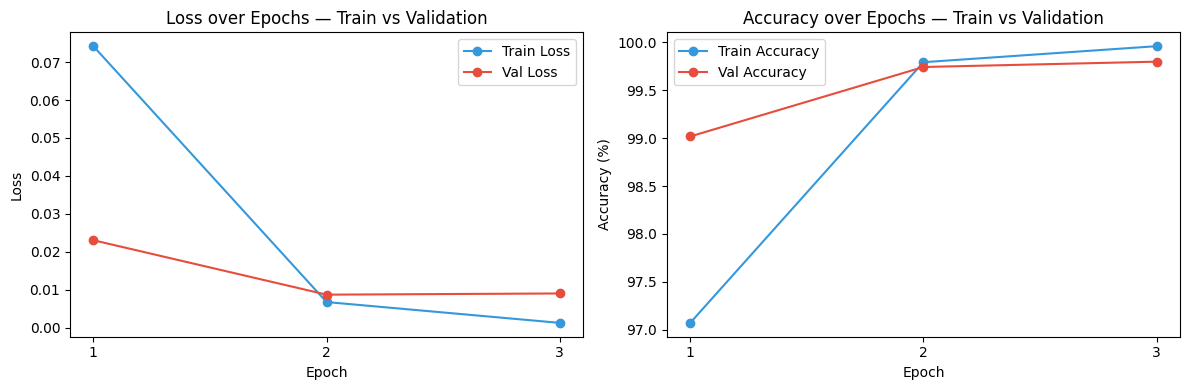

In [9]:
epochs_range = list(range(1, len(train_losses) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss 对比：训练 vs 验证 / Loss comparison: train vs validation
axes[0].plot(epochs_range, train_losses, 'o-', color='#3498db', label='Train Loss')
axes[0].plot(epochs_range, val_losses,   'o-', color='#e74c3c', label='Val Loss')
axes[0].set_title('Loss over Epochs — Train vs Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(epochs_range)
axes[0].legend()

# Accuracy 对比：训练 vs 验证 / Accuracy comparison: train vs validation
axes[1].plot(epochs_range, [v*100 for v in train_accuracies], 'o-', color='#3498db', label='Train Accuracy')
axes[1].plot(epochs_range, [v*100 for v in val_accuracies],   'o-', color='#e74c3c', label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs — Train vs Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(epochs_range)
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/distilbert_training_curves.png', dpi=150)
plt.show()

In [10]:
# 在测试集上计算 AUC（需要概率值，不能只用预测标签）
# Compute AUC on test set — requires probability scores, not just predicted labels
model.eval()
all_probs, all_preds_final, all_labels_final = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels']

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]  # 取类别 1（真新闻）的概率
        preds = outputs.logits.argmax(dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds_final.extend(preds.cpu().numpy())
        all_labels_final.extend(labels.numpy())

acc = accuracy_score(all_labels_final, all_preds_final)
auc = roc_auc_score(all_labels_final, all_probs)

print(f'Accuracy: {acc:.1%}')
print(f'AUC:      {auc:.1%}')
print()
print(f'Optimised LSTM (clean input):  Accuracy 97.9%  AUC 99.7%')
print(f'DistilBERT     (clean input):  Accuracy {acc:.1%}  AUC {auc:.1%}')

Accuracy: 99.8%
AUC:      100.0%

Optimised LSTM (clean input):  Accuracy 97.9%  AUC 99.7%
DistilBERT     (clean input):  Accuracy 99.8%  AUC 100.0%


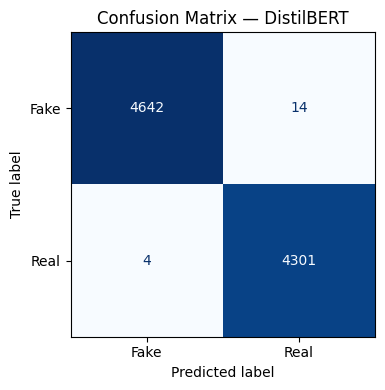

In [11]:
# 混淆矩阵 / Confusion matrix
cm = confusion_matrix(all_labels_final, all_preds_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — DistilBERT')
plt.tight_layout()
plt.savefig('../results/confusion_matrix_distilbert.png', dpi=150)
plt.show()